# Bilevel optimization

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/12 16:35:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Load Data

In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
df_og.shape

25/12/12 16:35:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


(33542, 95)

# Feature groups, define high cost and train-test-split

In [4]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
   # cost_stratum[(df['annual_cost_2017'] <= 10000)] = 1
   # cost_stratum[(df['annual_cost_2017'] > 10000) & (df['annual_cost_2017'] <= 20000)] = 2
   # cost_stratum[(df['annual_cost_2017'] > 20000) & (df['annual_cost_2017'] <= 30000)] = 3
    #cost_stratum[(df['annual_cost_2017'] > 30000) & (df['annual_cost_2017'] <= 40000)] = 4
   #cost_stratum[(df['annual_cost_2017'] > 40000) & (df['annual_cost_2017'] <= 50000)] = 5
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
target_col = "highcost_gt_200000"

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [5]:
# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=123)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))

val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

(23479, 96) (10063, 96)
Feature cols: 78


# Global undersampling using Push Pull

In [25]:
import os, pickle
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
import balancing_functions.pushpull_sampler
importlib.reload(balancing_functions.pushpull_sampler)
from balancing_functions.pushpull_sampler import PushPullSampler

In [ ]:
matcher = PushPullSampler(
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)

maj = train_pd[train_pd[target_col] == 0].copy()
minr = train_pd[train_pd[target_col] == 1].copy()

results_dir = "./ratio_sweep_results_pushpull_final_med_w"
os.makedirs(results_dir, exist_ok=True)

all_metrics = []

ratio_values = [1,2,3,4,5] #

minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]

    

In [9]:
ext = {
            "f1_min": float(3366.3280),
            "f1_max": float(4364.5781),
            "f2_min": float(0),
            "f2_max": float(154375.2973),
        }
for final_ratio in [1]:
    print("\n====================================")
    print(f"  Running PUSH–PULL sampling ratio={final_ratio:.2f}")
    print("====================================\n")
    
    undersampled_training_data, result, ext = matcher.solve_pushpull_normalized_MILP(
        df_cases=minr,
        df_controls=maj,
        exclude_cols_matching=["cost_stratum_2018"] + COST_COLUMNS,
        final_ratio=final_ratio,
        w=0.5,
        top_k_case_ctrl=60,
        L_pairs=10,
        K_factor=6.0,
        ext = None,
        verbose=True
    )

    # Save sampled data"""
    save_path = f"{results_dir}/ratio_{final_ratio:.2f}.csv"
    undersampled_training_data.to_csv(save_path, index=False)



  Running PUSH–PULL sampling ratio=1.00

>>> Distance computation will use 42 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
12 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE Inhibi

# Model Comparisons

In [6]:
analysis_cols = train_pd.columns # COST_COLUMNS
string_cost_cols = [col for col in analysis_cols 
                    if train_pd[col].dtype == 'object' or train_pd[col].dtype == 'string']
non_string_cost_cols = [col for col in analysis_cols if col not in string_cost_cols]
print("\nString-based COST_COLUMNS:")
print(string_cost_cols)
binary_cost_cols = []
for col in analysis_cols:
    vals = pd.unique(train_pd[col].dropna())
    if len(vals) == 2 and set(vals).issubset({0, 1}):
        binary_cost_cols.append(col)

print("\nBinary COST_COLUMNS (0/1 only):")
print(binary_cost_cols)
numeric_non_binary_cost_cols = [
    col for col in analysis_cols
    if pd.api.types.is_numeric_dtype(train_pd[col])
    and col not in binary_cost_cols
]

print("\nFinal numeric non-binary COST_COLUMNS:")
print(numeric_non_binary_cost_cols)


String-based COST_COLUMNS:
['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']

Binary COST_COLUMNS (0/1 only):
['highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE 

In [12]:
def compute_box_coverage(df_all, df_sel, features, lower=1, upper=99):
    """
    Computes multivariate (axis-aligned) coverage score of df_sel relative to df_all
    using percentile bounding boxes for robustness.
    Coverage = geometric mean of per-feature coverage.
    """
    cov = []
    for f in features:
        full_low, full_hi = np.percentile(df_all[f], [lower, upper])
        sel_low, sel_hi = np.percentile(df_sel[f], [lower, upper])

        full_range = full_hi - full_low
        sel_range = sel_hi - sel_low

        # If full range is 0 (degenerate), treat coverage as 1
        if full_range < 1e-9:
            print("Degenerate feature range", f, " ", full_range)
        else:
            #print("Full range", full_low, " ",full_hi, " selected ", sel_low, " ", sel_hi)
            cov.append(max(sel_range, 0.0) / full_range)

    return float(np.exp(np.mean(np.log(np.clip(cov, 1e-12, 1.0)))))

#results_dir = "./ratio_sweep_results_doublefac_extremepoint/"
metrics_master_path = f"{results_dir}/coverage_master.csv"


records = []

df_all = train_pd[train_pd[target_col] == 0]     # full majority population

for final_ratio in ratio_values:

    print("\n====================================")
    print(f"  Running coverage testing: ratio={final_ratio}")

    # Load the already-sampled dataset
    path = f"{results_dir}/ratio_{final_ratio:.2f}.csv"
    df_sel = pd.read_csv(path)

    # Extract only majority samples (minority always included)
    df_sel_maj = df_sel[df_sel[target_col] == 0]

    # Compute COST coverage
    coverage = compute_box_coverage(
        df_all=df_all,
        df_sel=df_sel_maj,
        features=numeric_non_binary_cost_cols)

    print(f"Coverage (COST_COLUMNS): {coverage:.4f}")
    print("n_selected_majority", len(df_sel_maj))
    print("n_total_majority", len(df_all))




  Running coverage testing: ratio=1
Coverage (COST_COLUMNS): 0.7074
n_selected_majority 660
n_total_majority 22819

  Running coverage testing: ratio=2
Coverage (COST_COLUMNS): 0.5535
n_selected_majority 1320
n_total_majority 22819

  Running coverage testing: ratio=3
Coverage (COST_COLUMNS): 0.4526
n_selected_majority 1980
n_total_majority 22819

  Running coverage testing: ratio=4
Coverage (COST_COLUMNS): 0.4568
n_selected_majority 2640
n_total_majority 22819

  Running coverage testing: ratio=5
Coverage (COST_COLUMNS): 0.4508
n_selected_majority 3300
n_total_majority 22819


In [13]:
from sklearn.metrics import pairwise_distances
X = train_pd.drop(columns=[target_col]+string_cost_cols)
X_cases = X[train_pd[target_col]==1].to_numpy()
X_ctrl  = X[train_pd[target_col]==0].to_numpy()

for final_ratio in [1, 2, 3, 4, 5]:
    print("\n====================================")
    print(f"  Running PUSH–PULL sampling ratio={final_ratio:.2f}")
    save_path = f"{results_dir}/ratio_{final_ratio:.2f}.csv"

    undersampled = pd.read_csv(save_path)
    
    sel = undersampled[undersampled[target_col]==0]  # selected controls from sampler
    X_sel  = sel.drop(columns=[target_col]+string_cost_cols).to_numpy()

    # Distance of selected controls to nearest case
    D_sel = pairwise_distances(X_sel, X_cases)
    nearest_to_case = D_sel.min(axis=1)

    print("mean distance selected LCC → nearest HCC:", nearest_to_case.mean())
    print("median distance:", np.median(nearest_to_case))
    print(undersampled.cost_stratum_2018.value_counts(dropna=False))



  Running PUSH–PULL sampling ratio=1.00
mean distance selected LCC → nearest HCC: 187460.2594513754
median distance: 198270.00839652642
cost_stratum_2018
3    660
0    605
1     29
2     26
Name: count, dtype: int64

  Running PUSH–PULL sampling ratio=2.00
mean distance selected LCC → nearest HCC: 184811.69632782994
median distance: 195803.11593123188
cost_stratum_2018
0    1197
3     660
1      74
2      49
Name: count, dtype: int64

  Running PUSH–PULL sampling ratio=3.00
mean distance selected LCC → nearest HCC: 187492.47897341114
median distance: 197209.57155152754
cost_stratum_2018
0    1842
3     660
1      80
2      58
Name: count, dtype: int64

  Running PUSH–PULL sampling ratio=4.00
mean distance selected LCC → nearest HCC: 188056.09616385668
median distance: 197213.0046279621
cost_stratum_2018
0    2463
3     660
1     109
2      68
Name: count, dtype: int64

  Running PUSH–PULL sampling ratio=5.00
mean distance selected LCC → nearest HCC: 187657.7293360489
median distance: 

In [40]:
metrics_master_path

'./ratio_sweep_results_pushpull_final_med_w/metrics_master.csv'

In [41]:
metrics_master_path = f"{results_dir}/metrics_master.csv"
for final_ratio in ratio_values:
    print("\n====================================")
    print(f"  Running PUSH–PULL sampling ratio={final_ratio:.2f}")
    print("====================================\n")
    save_path = f"{results_dir}/ratio_{final_ratio:.2f}.csv"

    undersampled_training_data = pd.read_csv(save_path)
    # Train OCT
    balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
        X_train=undersampled_training_data[feature_cols],
        y_train=undersampled_training_data[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=depths_M2,
        minbuckets=minbuckets_M2,
        cps=cps_M2,
    )

    # Evaluate
    metrics = evaluate_binary_oct(
        balanced_model, X_test, y_test, preprocessor, feature_names,
        results_dir = results_dir, ratio = final_ratio
    )

    row = metrics.copy()
    row["ratio"] = final_ratio

    # Append
    pd.DataFrame([row]).to_csv(
        metrics_master_path,
        mode="a",
        header=not os.path.exists(metrics_master_path),
        index=False,
    )

    all_metrics.append(row)



  Running PUSH–PULL sampling ratio=1.00

→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed


...

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
✓ Saved OCT predictions to: ./ratio_sweep_results_pushpull_final_med_w/predictions/oct_predictions_ratio_5.00.csv
✓ Saved split table (2 splits) to: ./ratio_sweep_results_pushpull_final_med_w/oct_tree_ratio_5.00_splits.csv
AUC score: 0.761
PR-AUC (Average Precision): 0.094
Sensitivity (Recall): 0.638
Specificity: 0.895
Balanced (G-mean) recall: 0.638
Balanced (G-mean) specificity: 0.895
Sensitivity (default): 0.638
Specificity (default): 0.895
Number of leaves: 3


[ Warning: The type of y (Any) does not match the original target type (Int64)


./ratio_sweep_results_pushpull_final_med_w


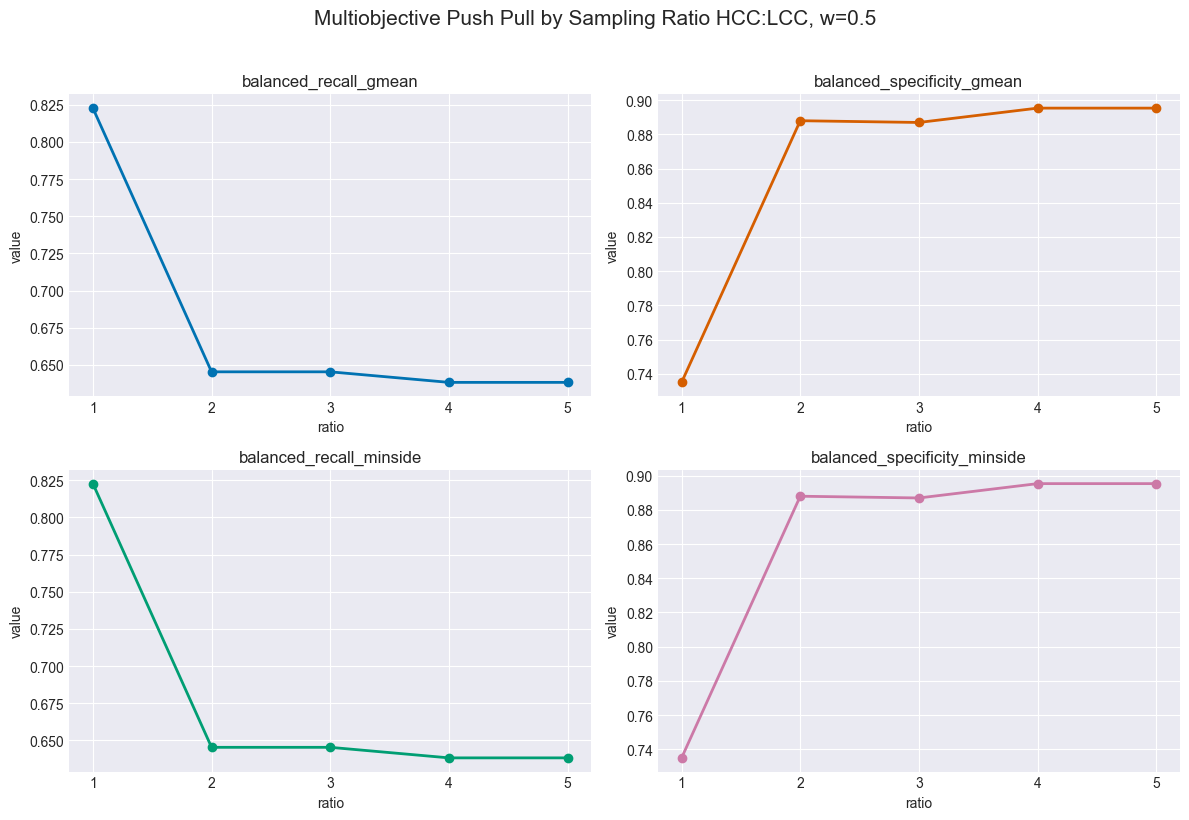

In [ ]:
import re,os
import pickle
print(results_dir)
metrics_master_path = f"{results_dir}/metrics_master.csv"
ratio_values = [1,2,3,4,5]
records = pd.read_csv(metrics_master_path)

# Create DataFrame sorted by w
df = pd.DataFrame(records).sort_values("ratio").reset_index(drop=True)
plt.style.use("seaborn-v0_8-darkgrid")
thr = df["optimal_threshold"]
metrics_to_plot = ["optimal_f1", "sensitivity", "specificity", "auc"] # optimal_f1
metrics_to_plot = ["balanced_recall_gmean", "balanced_specificity_gmean", "balanced_recall_minside", "balanced_specificity_minside"] # optimal_f1
titles = ["Max F1", f"Recall (max F1)", f"Specificity (max F1)", f"ROC AUC"]
titles = metrics_to_plot
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]


# ---------------------------
# Separate subplot grid
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, metric, title, c in zip(axes, metrics_to_plot, titles, colors):
    ax.plot(df["ratio"], df[metric], marker="o", color=c, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("ratio")
    ax.set_ylabel("value")
    ax.set_xticks(df["ratio"])
    ax.grid(True)

fig.suptitle("Multiobjective Push Pull by Sampling Ratio HCC:LCC, w=0.5", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

""" compare vanilla: Balanced (G-mean) recall: 0.454
Balanced (G-mean) specificity: 0.651"""

# Inspect if the subgroups defined by Vanilla OCT now have better AUC

In [6]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import calculate_auc_by_vanilla_subgroups


2025-12-12 16:35:41,848 WARNING  Interpretable AI license expires soon: 2025-12-31T00:00:00. If you need to renew, please send us the following machine ID:
da2d87f307115a4389e740fa6b3796f3ca586f217a49634cef5fb2b2945f7cea


In [ ]:
# Load vanilla OCT predictions (contains leaf_assignment)
vanilla_pred_path = "vanilla_oct/predictions/oct_predictions.csv"

# Load balanced OCT predictions for ratio 1
balanced_pred_path = f"ratio_sweep_results_pushpull_final_med_w/oct_predictions_ratio_1.00.csv"
#balanced_pred_path = "random_undersample_oct/predictions/oct_predictions.csv"
# Calculate AUC by subgroups using leaf_assignment from vanilla OCT
subgroup_results = calculate_auc_by_vanilla_subgroups(
    anchor_model_pred_path=vanilla_pred_path,
    y_test=y_test,
    test_model_pred_path=balanced_pred_path 
)


print("\nSubgroup Details:")
print(subgroup_results['subgroups'].to_string())



Subgroup Details:
   subgroup_id  n_samples  n_positive  n_negative  positive_rate  anchor_model_roc_auc  anchor_model_pr_auc  test_model_roc_auc  test_model_pr_auc
0            3       3262          96        3166       0.029430                   0.5             0.029430            0.781707           0.072706
1            4         45           0          45       0.000000                   NaN                  NaN                 NaN                NaN
2            5       1725          45        1680       0.026087                   0.5             0.026087            0.792910           0.066289


In [18]:
# Load balanced OCT predictions for ratio 1
random_pred_path = "random_undersample_oct/predictions/oct_predictions.csv"
balanced_pred_path2 = f"ratio_sweep_results_pushpull_extremepoint_med_w/oct_predictions_ratio_1.00.csv"

# Calculate AUC by subgroups using leaf_assignment from vanilla OCT
subgroup_results = calculate_auc_by_vanilla_subgroups(
    anchor_model_pred_path=  balanced_pred_path2,
    y_test=y_test,
    test_model_pred_path= balanced_pred_path
)


print("\nSubgroup Details:")
print(subgroup_results['subgroups'].to_string())




Subgroup Details:
   subgroup_id  n_samples  n_positive  n_negative  positive_rate  anchor_model_roc_auc  anchor_model_pr_auc  test_model_roc_auc  test_model_pr_auc
0            3       2172          10        2162       0.004604                   0.5             0.004604            0.648451           0.010388
1            5       1508          16        1492       0.010610                   0.5             0.010610            0.625084           0.014643
2            6        231          12         219       0.051948                   0.5             0.051948            0.666857           0.079236
3           10        414          13         401       0.031401                   0.5             0.031401            0.626223           0.042381
4           11        331          22         309       0.066465                   0.5             0.066465            0.588482           0.082954
5           12        228          27         201       0.118421                   0.5             